In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn import linear_model

import warnings
warnings.filterwarnings("ignore")

In [28]:
df = pd.read_csv('Hitters.csv')
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [29]:
df = df.dropna(subset=['Salary'])
df = pd.get_dummies(df, columns=['League','Division','NewLeague'], drop_first=True)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [30]:
X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPRegressor())
])

params_grid = {
    'nn__hidden_layer_sizes': [(5,5,5), (10,), (100,), (10,10), (10,10,10), (100,100), (100,100,100)],
    'nn__activation': ['tanh','relu','logistic'],
    'nn__alpha': [0.1,0.01,0.001]
}

grid_nn = GridSearchCV(estimator=pipeline, n_jobs=-1, cv=5, scoring='r2', param_grid=params_grid)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('nn', MLPRegressor())]),
             n_jobs=-1,
             param_grid={'nn__activation': ['tanh', 'relu', 'logistic'],
                         'nn__alpha': [0.1, 0.01, 0.001],
                         'nn__hidden_layer_sizes': [(5, 5, 5), (10,), (100,),
                                                    (10, 10), (10, 10, 10),
                                                    (100, 100),
                                                    (100, 100, 100)]},
             scoring='r2')

In [32]:
grid.best_params_

{'nn__activation': 'relu',
 'nn__alpha': 0.01,
 'nn__hidden_layer_sizes': (100, 100, 100)}

# R^2

In [33]:
pred = grid.best_estimator_.predict(X_test)
r2_score(y_pred=pred, y_true=y_test)

0.3224689877067397

# Gráfica calibración:

In [20]:
def calibracion(predicciones, y, bins):
    df_calibracion = pd.DataFrame({
        'predicciones': predicciones,
        'y': y
    })
    df_calibracion['bins'] = pd.qcut(df_calibracion['predicciones'], q=bins, labels=False, duplicates='drop') + 1
    grouped = df_calibracion.groupby('bins').mean()

    plt.plot(grouped.predicciones, grouped.y, label = 'Modelo', marker = 'o')
    plt.plot(grouped.predicciones, grouped.predicciones, label = 'Real', marker = 'o')
    plt.grid()
    plt.legend()
    plt.xlabel('Predicción')
    plt.ylabel('Real')

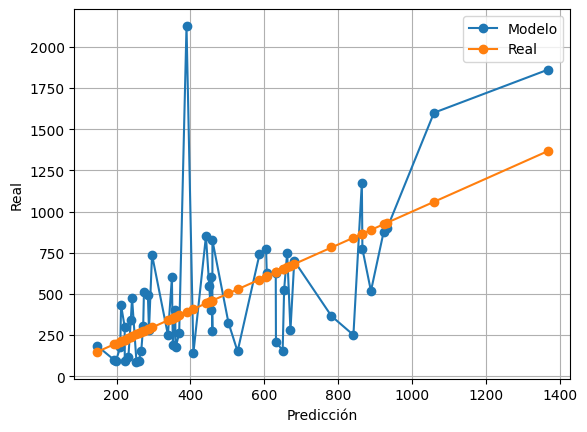

In [21]:
calibracion(predicciones, y_test, 100)

# Conclusiones

En la gráfica podemos ver que hay mucho margen de error y esta no está tan bien ajustada a la realidad. Al mismo tiempo nuestro R^2 es de 32% lo cual tampoco es muy bueno. Podemos ver que hay mucho espacio para mejorar. El mejor parámetro de activación es el de Relu, en donde utilizamos 3 capas de 100 neuronas cada una.
